<div style="
  background: linear-gradient(145deg, #0f172a, #1e293b);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #f8fafc;
  box-shadow: 0 6px 14px rgba(0,0,0,0.25);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #06b6d4, #3b82f6, #8b5cf6);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  <b>06. 📊 CSV Data Visualizer & Dashboard</b>
</div>


### 📌 Project Overview
In this project, we build a Sales Performance Dashboard using Pandas and Matplotlib.
We'll generate a sample sales dataset programmatically, perform data conversions, calculate aggregations, and compile a 2x2 grid dashboard featuring bar charts, pie splits, trend curves, and correlation scatter plots.

#### 🔑 Key Concepts Covered:
- Programmatic generation of mock CSV transaction histories
- Converting datetime series and computing calculated fields in `pandas`
- Grouping and aggregating dataset features via `.groupby()` and sum/average functions
- Styling grid canvas layouts with `matplotlib.subplots`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

def build_mock_sales_csv(dest_file='sales_data.csv'):
    headers = ['Date', 'Product', 'Region', 'Units', 'UnitPrice']
    rows = [
        ['2026-01-01', 'Laptop', 'North', 15, 80000],
        ['2026-01-02', 'Phone', 'South', 30, 35000],
        ['2026-01-03', 'Tablet', 'East', 25, 20000],
        ['2026-01-04', 'Laptop', 'West', 8, 80000],
        ['2026-01-05', 'Phone', 'North', 45, 35000],
        ['2026-01-06', 'Tablet', 'South', 12, 20000],
        ['2026-01-07', 'Laptop', 'East', 18, 80000],
        ['2026-01-08', 'Phone', 'West', 22, 35000],
        ['2026-01-09', 'Tablet', 'North', 35, 20000],
        ['2026-01-10', 'Laptop', 'South', 10, 80000]
    ]
    with open(dest_file, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(headers)
        writer.writerows(rows)
    print(f'Generated mock transaction database: "{dest_file}"')

def perform_aggregations(dest_file):
    df = pd.read_csv(dest_file)
    df['Date'] = pd.to_datetime(df['Date'])
    df['Revenue'] = df['Units'] * df['UnitPrice']
    
    # Compute metrics
    tot_rev = df['Revenue'].sum()
    tot_units = df['Units'].sum()
    mean_order = df['Revenue'].mean()
    
    print('='*50)
    print('📊 BUSINESS PERFORMANCE KPIs')
    print('='*50)
    print(f'Total Gross Revenue  : ₹{tot_rev:,.2f}')
    print(f'Total Volume Sold     : {tot_units} units')
    print(f'Mean Transaction Value: ₹{mean_order:,.2f}')
    print('='*50)
    
    by_product = df.groupby('Product')['Revenue'].sum()
    by_region = df.groupby('Region')['Revenue'].sum()
    by_date = df.groupby('Date')['Revenue'].sum()
    
    return df, by_product, by_region, by_date

Generated mock transaction database: "sales_data.csv"
📊 BUSINESS PERFORMANCE KPIs
Total Gross Revenue  : ₹8,915,000.00
Total Volume Sold     : 220 units
Mean Transaction Value: ₹891,500.00


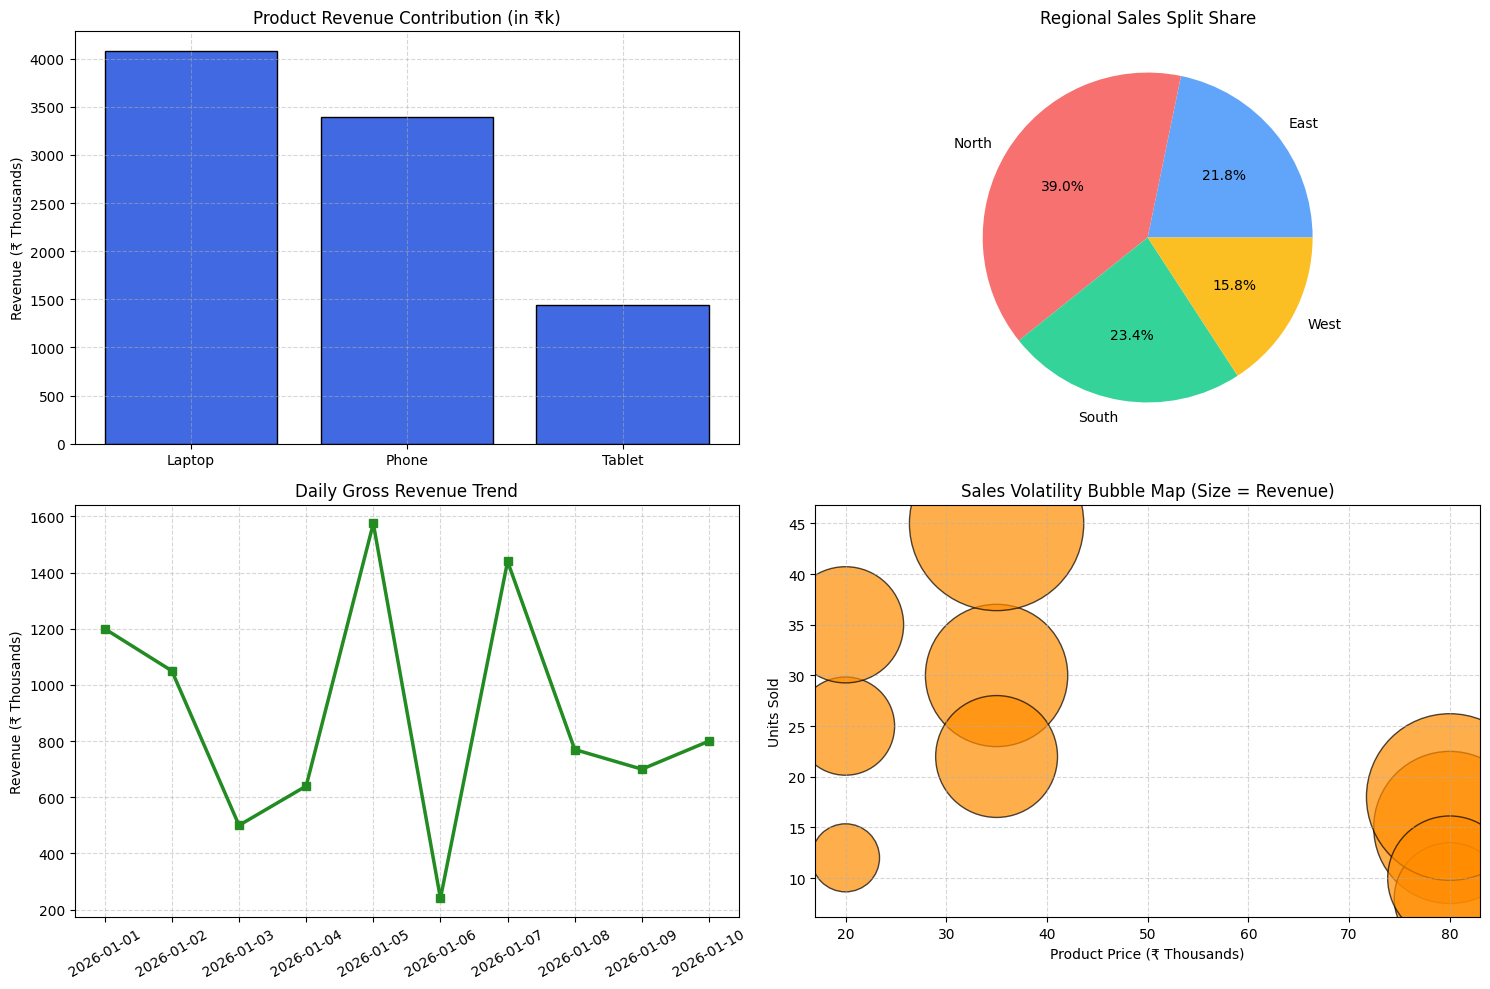

In [2]:
build_mock_sales_csv()
df, product_sales, region_sales, date_sales = perform_aggregations('sales_data.csv')

# Compile multi-chart matplotlib Dashboard
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Subplot 1: Bar chart for Product Performance
axs[0, 0].bar(product_sales.index, product_sales.values / 1000, color='royalblue', edgecolor='black')
axs[0, 0].set_title('Product Revenue Contribution (in ₹k)')
axs[0, 0].set_ylabel('Revenue (₹ Thousands)')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Pie chart for Regional splits
axs[0, 1].pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%', colors=['#60a5fa', '#f87171', '#34d399', '#fbbf24'])
axs[0, 1].set_title('Regional Sales Split Share')

# Subplot 3: Trend Curve over dates
axs[1, 0].plot(date_sales.index, date_sales.values / 1000, marker='s', color='forestgreen', linewidth=2.5)
axs[1, 0].set_title('Daily Gross Revenue Trend')
axs[1, 0].set_ylabel('Revenue (₹ Thousands)')
axs[1, 0].tick_params(axis='x', rotation=30)
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

# Subplot 4: Volatility Scatter bubble plot
axs[1, 1].scatter(df['UnitPrice'] / 1000, df['Units'], s=df['Revenue'] / 100, alpha=0.7, color='darkorange', edgecolors='black')
axs[1, 1].set_title('Sales Volatility Bubble Map (Size = Revenue)')
axs[1, 1].set_xlabel('Product Price (₹ Thousands)')
axs[1, 1].set_ylabel('Units Sold')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()